# Применение решающих деревьев в реальных задачах

Вспомним с одного из предыдущих занятий набор данных об автомобилях и попробуем применить ек нему не линейную регрессию, а деревья принятия решений.


В наборе данных содержится **140,904** записей с **12** признаками. Задачей является предсказание **цены (`Price`)** машины на основании имеющихся признаков.

## описание признаков

| Имя признака    | Тип данных     | Описание                                                                          |
| --------------- | -------------- | --------------------------------------------------------------------------------- |
| `Brand`         | Категориальный | Производитель автомобиля (к примеру, Honda, Toyota, BMW)                          |
| `Model_Name`    | Категориальный | Название модели автомобиля                                                        |
| `Model_Variant` | Категориальный | Комплектация автомобиля                                                           |
| `Car_Type`      | Категориальный | Тип кузова автомобиля                                                            |
| `Transmission`  | Категориальный | Ручная или автоматическая коробка передач                                         |
| `Fuel_Type`     | Категориальный | Тип топлива                                                                       |
| `Year`          | Числовой       | Год производства автомобиля                                                       |
| `Kilometers`    | Числовой       | Пробег автомобиля                                                                 |
| `Owner`         | Ординальный    | Сколько было владельцев у автомобиля (1,2, или 3 и больше)                        |
| `State`         | Категориальный | Регион Индии, где автомобиль выставлен на продажу                                 |
| `Accidental`    | Категориальный | Участвовал ли автомобиль в аварии (да/нет)                                        |
| `Price`         | Числовой       | **Целевой признак**. Цена автомобиля в Индийских рупиях                           |


В наборе данных есть много категориальных признаков, есть ординальные признаки и совсем немного числовых.

In [1]:
import numpy as np
import pandas as pd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import root_mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from scipy.stats import randint, uniform, loguniform
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pydotplus
from IPython.display import Image, display

def plot_tree(clf):
    """ Функция для отрисовки обученного дерева. """
    dot_data = export_graphviz(clf, out_file=None, 
                             filled=True, rounded=True,  
                             special_characters=True)
    graph = pydotplus.graph_from_dot_data(dot_data)  
    display(Image(graph.create_png()))

In [3]:
# ! unzip ./car-dataset.zip

In [4]:
df = pd.read_csv('./Car Sell Dataset.csv')

In [5]:
df.isna().sum()

Brand            0
Model Name       0
Model Variant    0
Car Type         0
Transmission     0
Fuel Type        0
Year             0
Kilometers       0
Owner            0
State            0
Accidental       0
Price            0
dtype: int64

В этот раз применим к признакам LabelEncoder. Он назначит категориям числа $1,2,3...$ и не будет порождать новые столбцы.

In [6]:
# Формируем выборки
X = df.drop(columns=["Price"])
Y = df["Price"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=51, test_size=0.2)

Y_train_transformed = np.log(Y_train)
Y_test_transformed = np.log(Y_test)


# Encode categorical features
cat_cols = ['Brand', 'Model Name', 'Model Variant', 'Car Type',
            'Transmission', 'Fuel Type', 'Owner', 'State', 'Accidental']

X_train_transformed = X_train.copy()
X_test_transformed = X_test.copy()
le = LabelEncoder()
for col in cat_cols:
    X_train_transformed[col] = le.fit_transform(X_train_transformed[col])
    X_test_transformed[col] = le.transform(X_test_transformed[col])

Если мы просто применим модель, то она ожидаемо переобучится.

In [7]:
model = DecisionTreeRegressor()

model.fit(X_train_transformed, Y_train_transformed)

print("R2 на обучающей выборке: ", r2_score(Y_train_transformed, model.predict(X_train_transformed)))
print("R2 на тестовой выборке:  ", r2_score(Y_test_transformed, model.predict(X_test_transformed)))

R2 на обучающей выборке:  1.0
R2 на тестовой выборке:   -0.502699053351781


Давайте попробуем руками подбирать параметры:

In [8]:
model = DecisionTreeRegressor(max_depth=100, min_samples_split=5, min_samples_leaf=1, ccp_alpha=1e-4)

model.fit(X_train_transformed, Y_train_transformed)

print("R2 на обучающей выборке: ", r2_score(Y_train_transformed, model.predict(X_train_transformed)))
print("R2 на тестовой выборке:  ", r2_score(Y_test_transformed, model.predict(X_test_transformed)))

R2 на обучающей выборке:  0.272354137642251
R2 на тестовой выборке:   0.27402290135817187


И у нас без особых усилий получается превзойти показатели, которые имела линейная регрессия на том же наборе данных.

In [9]:

model = DecisionTreeRegressor()

param_dist = {
    "max_depth": randint(20, 100),
    "min_samples_split": randint(2, 30),
    "min_samples_leaf": randint(1, 30),
    "ccp_alpha": loguniform(1e-9, 1e-2) 
}

rs = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=100,
                        cv=5, scoring="r2", n_jobs=-1, random_state=42, verbose=1)
rs.fit(X_train_transformed, Y_train_transformed)
model = rs.best_estimator_

print("R2 на обучающей выборке: ", r2_score(Y_train_transformed, model.predict(X_train_transformed)))
print("R2 на тестовой выборке:  ", r2_score(Y_test_transformed, model.predict(X_test_transformed)))
print("Параметры модели:")
print(model.get_params())

Fitting 5 folds for each of 100 candidates, totalling 500 fits
R2 на обучающей выборке:  0.2763854539339814
R2 на тестовой выборке:   0.27639774113434457
Параметры модели:
{'ccp_alpha': 5.069309786349802e-05, 'criterion': 'squared_error', 'max_depth': 94, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 24, 'min_samples_split': 28, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


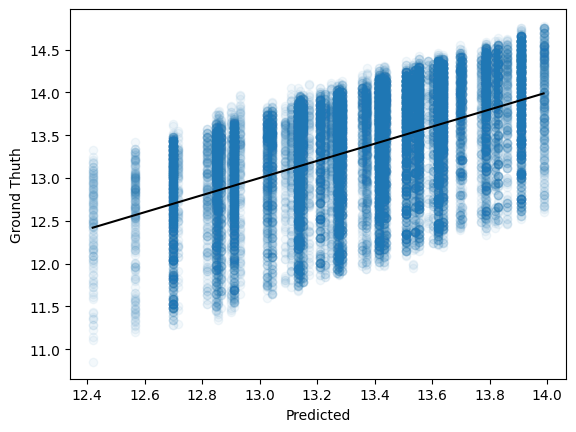

In [10]:
Y_test_pred = model.predict(X_test_transformed)

plt.scatter(Y_test_pred, Y_test_transformed,  alpha=0.05)
plt.xlabel("Predicted")
plt.ylabel("Ground Thuth")


t = np.linspace(Y_test_pred.min(), Y_test_pred.max(),100)

plt.plot(t,t,color="black")

Также мы можем попробовать применить к имеющимся столбцам разные преобразования, к примеру One-Hot encoding.

In [11]:
from sklearn.preprocessing import TargetEncoder, OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

# Категориальные признаки с большим количеством значений
categorical_big_cols = ['Brand', 'Model Name', 'Model Variant']

# Ординальный признак и порядок значений
ordinal_columns = ['Owner']
ordinals_order = [["1st", "2nd", "3rd+"]]

# Категориальные столбцы
categorical_columns = ['Car Type', 'Transmission', 'Fuel Type', 'State', 'Accidental']

numerical_columns = ["Kilometers"]
 
tranformer = ColumnTransformer(transformers=[
    ("categorical", OneHotEncoder(drop="first"), categorical_columns),
    ("cat", OneHotEncoder(drop="first"), categorical_big_cols),
    ("ordinal", OrdinalEncoder(categories=ordinals_order), ordinal_columns),
    ("numeric", StandardScaler(), numerical_columns),
],
remainder="passthrough")# Остальные столбцы не меняются

X_train_transformed = tranformer.fit_transform(X_train, Y_train_transformed)
X_test_transformed = tranformer.transform(X_test)

Времени это заняло прилично, а качество не увеличило.

In [12]:
model = DecisionTreeRegressor()

param_dist = {
    "max_depth": randint(20, 100),
    "min_samples_split": randint(2, 30),
    "min_samples_leaf": randint(1, 30),
    "ccp_alpha": loguniform(1e-9, 1e-2) 
}

rs = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=100,
                        cv=5, scoring="r2", n_jobs=-1, random_state=42, verbose=1)
rs.fit(X_train_transformed, Y_train_transformed)
model = rs.best_estimator_

print("R2 на обучающей выборке: ", r2_score(Y_train_transformed, model.predict(X_train_transformed)))
print("R2 на тестовой выборке:  ", r2_score(Y_test_transformed, model.predict(X_test_transformed)))
print("Параметры модели:")
print(model.get_params())

Fitting 5 folds for each of 100 candidates, totalling 500 fits
R2 на обучающей выборке:  0.2761557237340062
R2 на тестовой выборке:   0.2764858259178199
Параметры модели:
{'ccp_alpha': 4.813582478417197e-05, 'criterion': 'squared_error', 'max_depth': 88, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 28, 'min_samples_split': 17, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


А также мы можем применить Target Encoding, который каждую категорию заменит на среднее значение целевой переменной по этой категории.

In [13]:

tranformer = ColumnTransformer(transformers=[
    ("categorical", TargetEncoder(target_type="continuous"), categorical_columns),
    ("cat", TargetEncoder(target_type="continuous"), categorical_big_cols),
    ("ordinal", OrdinalEncoder(categories=ordinals_order), ordinal_columns),
    ("numeric", StandardScaler(), numerical_columns),
],
remainder="passthrough")# Остальные столбцы не меняются

X_train_transformed = tranformer.fit_transform(X_train, Y_train_transformed)
X_test_transformed = tranformer.transform(X_test)

Так качество уже возрастёт, причём не в ущерб времени обучения.

In [14]:
model = DecisionTreeRegressor()

param_dist = {
    "max_depth": randint(20, 100),
    "min_samples_split": randint(2, 30),
    "min_samples_leaf": randint(1, 30),
    "ccp_alpha": loguniform(1e-9, 1e-2) 
}

rs = RandomizedSearchCV(model, param_distributions=param_dist, n_iter=100,
                        cv=5, scoring="r2", n_jobs=-1, random_state=42, verbose=1)
rs.fit(X_train_transformed, Y_train_transformed)
model = rs.best_estimator_

print("R2 на обучающей выборке: ", r2_score(Y_train_transformed, model.predict(X_train_transformed)))
print("R2 на тестовой выборке:  ", r2_score(Y_test_transformed, model.predict(X_test_transformed)))
print("Параметры модели:")
print(model.get_params())

Fitting 5 folds for each of 100 candidates, totalling 500 fits
R2 на обучающей выборке:  0.2849903157288426
R2 на тестовой выборке:   0.282341939890977
Параметры модели:
{'ccp_alpha': 4.8185656793309416e-05, 'criterion': 'squared_error', 'max_depth': 44, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 29, 'min_samples_split': 19, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': None, 'splitter': 'best'}


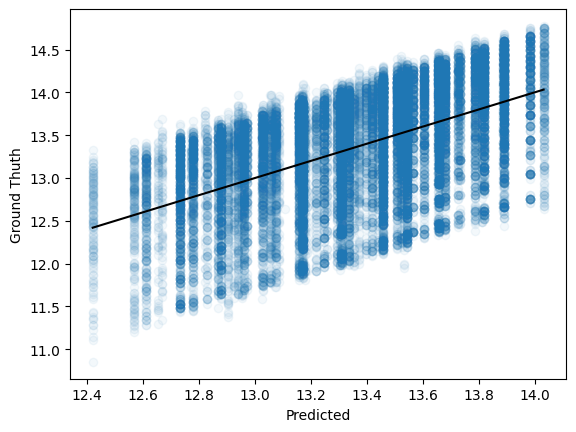

In [15]:
Y_test_pred = model.predict(X_test_transformed)

plt.scatter(Y_test_pred, Y_test_transformed,  alpha=0.05)
plt.xlabel("Predicted")
plt.ylabel("Ground Thuth")


t = np.linspace(Y_test_pred.min(), Y_test_pred.max(),100)

plt.plot(t,t,color="black")